# Лабораторная работа по анализу данных медицинского страхования

## 1. Импорт библиотек и настройка

In [1]:
# Подавление предупреждений
import warnings
warnings.filterwarnings('ignore')

# Основные библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Статистика
from scipy import stats
from scipy.stats import shapiro, normaltest, pearsonr, spearmanr
from scipy.stats import f_oneway, kruskal, mannwhitneyu, ttest_ind
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Машинное обучение
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.pipeline import Pipeline

# Настройки
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

print("✓ Библиотеки импортированы успешно!")

✓ Библиотеки импортированы успешно!


## 2. Загрузка данных

In [2]:
# Загрузка датасета
df = pd.read_csv('insurance.csv')

print("=" * 80)
print("ДАТАСЕТ ЗАГРУЖЕН")
print("=" * 80)
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Память: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")
print("\nПервые 5 строк:")
display(df.head())

ДАТАСЕТ ЗАГРУЖЕН
Размер: 1338 строк × 7 столбцов
Память: 255.18 KB

Первые 5 строк:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 3. Общая информация о данных

In [3]:
print("Информация о данных:")
print("=" * 80)
df.info()

print("\n" + "=" * 80)
print("Пропущенные значения:")
print("=" * 80)
missing = df.isnull().sum()
print(missing)
if missing.sum() == 0:
    print("\n✓ Пропущенных значений НЕТ")

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Пропущенные значения:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

✓ Пропущенных значений НЕТ


## 4. Описательная статистика

In [4]:
print("Числовые признаки:")
display(df.describe().T)

print("\nРасширенная статистика:")
numeric_cols = df.select_dtypes(include=[np.number]).columns
extended_stats = pd.DataFrame({
    'Среднее': df[numeric_cols].mean(),
    'Медиана': df[numeric_cols].median(),
    'Ст.откл.': df[numeric_cols].std(),
    'Асимметрия': df[numeric_cols].skew(),
    'Эксцесс': df[numeric_cols].kurtosis(),
    'Мин': df[numeric_cols].min(),
    'Макс': df[numeric_cols].max()
})
display(extended_stats)

print("\nКатегориальные признаки:")
print("=" * 80)
for col in ['sex', 'smoker', 'region']:
    print(f"\n{col.upper()}:")
    vc = df[col].value_counts()
    vp = df[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Количество': vc, 'Процент': vp.round(2)})
    display(summary)

Числовые признаки:


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



Расширенная статистика:


,Среднее,Медиана,Ст.откл.,Асимметрия,Эксцесс,Мин,Макс
age,39.207025,39.000,14.049960,0.055673,-1.245088,18.0000,64.00000
bmi,30.663397,30.400,6.098187,0.284047,-0.050732,15.9600,53.13000
children,1.094918,1.000,1.205493,0.938380,0.202454,0.0000,5.00000
charges,13270.422265,9382.033,12110.011237,1.515880,1.606299,1121.8739,63770.42801



Категориальные признаки:

SEX:


,Количество,Процент
sex,,
male,676,50.52
female,662,49.48



SMOKER:


,Количество,Процент
smoker,,
no,1064,79.52
yes,274,20.48



REGION:


,Количество,Процент
region,,
southeast,364,27.20
southwest,325,24.29
northwest,325,24.29
northeast,324,24.22


## 5. Визуализация целевой переменной

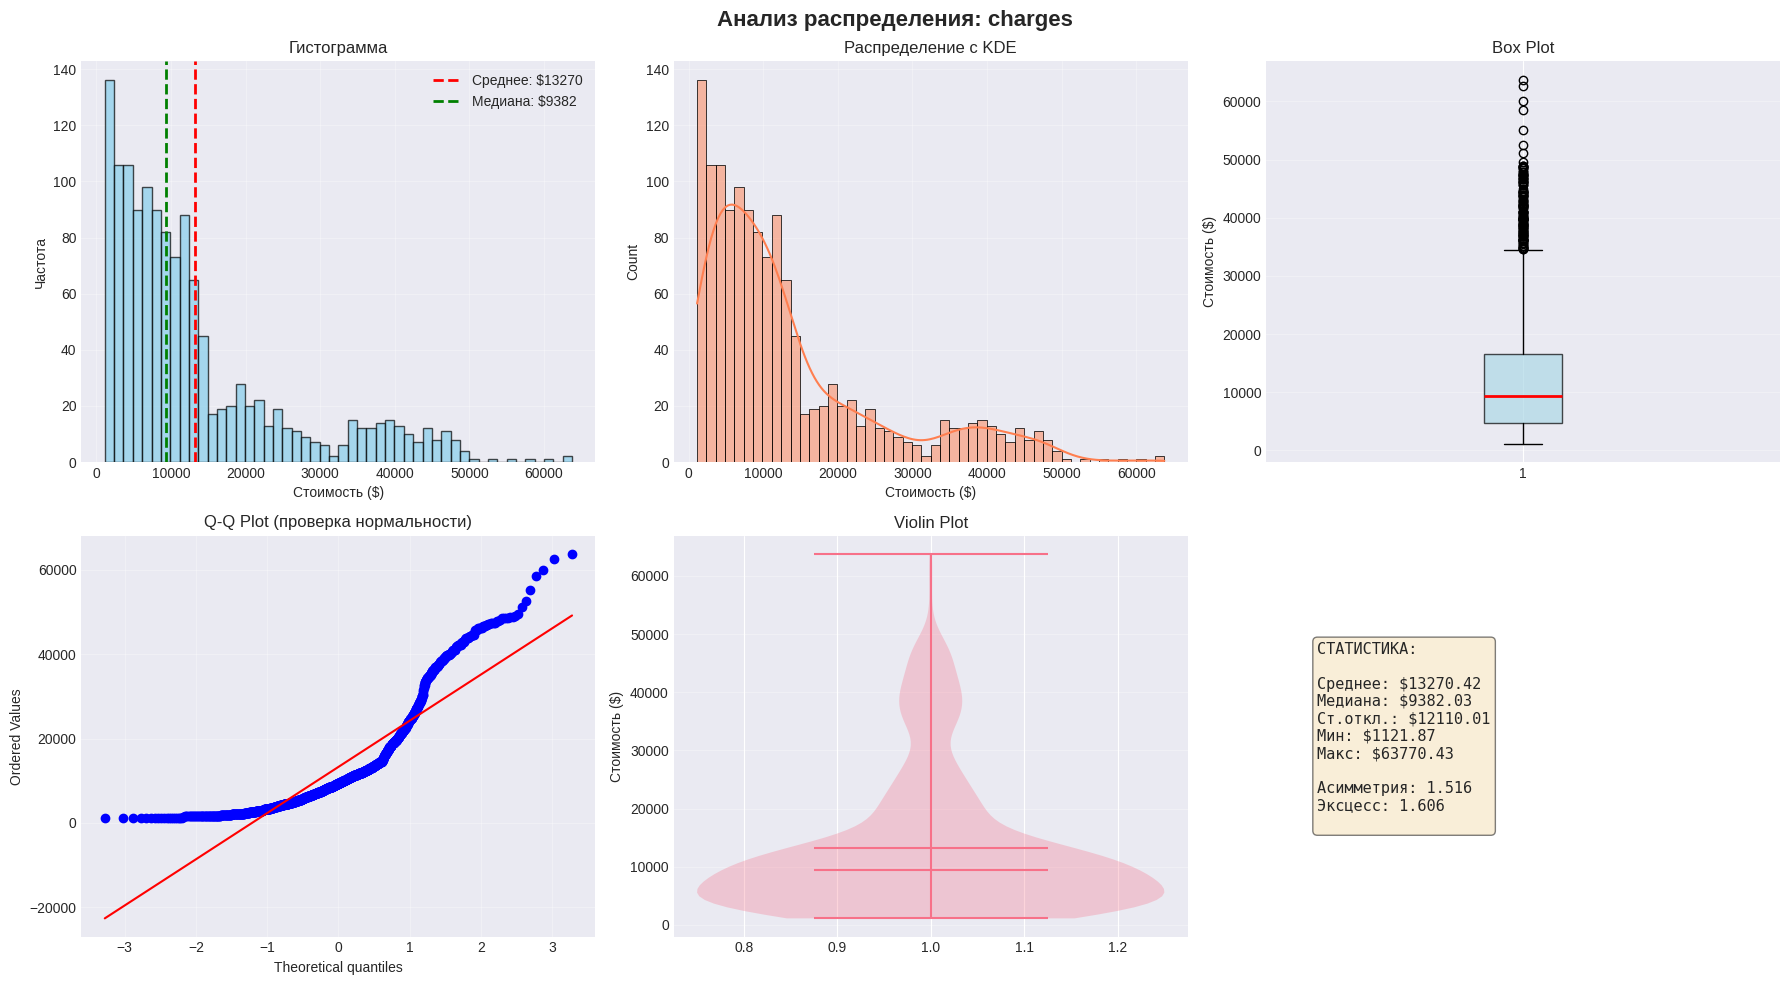

In [5]:
# Комплексная визуализация целевой переменной
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Анализ распределения: charges', fontsize=16, fontweight='bold')

# Гистограмма
axes[0, 0].hist(df['charges'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['charges'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: ${df["charges"].mean():.0f}')
axes[0, 0].axvline(df['charges'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: ${df["charges"].median():.0f}')
axes[0, 0].set_xlabel('Стоимость ($)')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Гистограмма')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Гистограмма с KDE
sns.histplot(df['charges'], kde=True, bins=50, ax=axes[0, 1], color='coral')
axes[0, 1].set_xlabel('Стоимость ($)')
axes[0, 1].set_title('Распределение с KDE')
axes[0, 1].grid(True, alpha=0.3)

# Box plot
bp = axes[0, 2].boxplot(df['charges'], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2))
axes[0, 2].set_ylabel('Стоимость ($)')
axes[0, 2].set_title('Box Plot')
axes[0, 2].grid(True, alpha=0.3, axis='y')

# Q-Q plot
stats.probplot(df['charges'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (проверка нормальности)')
axes[1, 0].grid(True, alpha=0.3)

# Violin plot
parts = axes[1, 1].violinplot([df['charges']], vert=True, showmeans=True, showmedians=True)
axes[1, 1].set_ylabel('Стоимость ($)')
axes[1, 1].set_title('Violin Plot')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Статистика
stats_text = f'''СТАТИСТИКА:

Среднее: ${df['charges'].mean():.2f}
Медиана: ${df['charges'].median():.2f}
Ст.откл.: ${df['charges'].std():.2f}
Мин: ${df['charges'].min():.2f}
Макс: ${df['charges'].max():.2f}

Асимметрия: {df['charges'].skew():.3f}
Эксцесс: {df['charges'].kurtosis():.3f}
'''
axes[1, 2].text(0.1, 0.5, stats_text, transform=axes[1, 2].transAxes,
                fontsize=11, verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 6. Тесты на нормальность

In [6]:
print("ТЕСТЫ НОРМАЛЬНОСТИ: charges")

# Shapiro-Wilk test
if len(df) <= 5000:
    stat_sw, p_sw = shapiro(df['charges'])
    print(f"\n1. Shapiro-Wilk test:")
    print(f"   Статистика: {stat_sw:.6f}")
    print(f"   p-value: {p_sw:.6e}")
    print(f"   Вывод: {'Отвергаем H0 - НЕ нормальное' if p_sw < 0.05 else 'Не отвергаем H0 - нормальное'}")

# D'Agostino-Pearson test
stat_dp, p_dp = normaltest(df['charges'])
print(f"\n2. D'Agostino-Pearson test:")
print(f"   Статистика: {stat_dp:.6f}")
print(f"   p-value: {p_dp:.6e}")
print(f"   Вывод: {'Отвергаем H0 - НЕ нормальное' if p_dp < 0.05 else 'Не отвергаем H0 - нормальное'}")

print("ЗАКЛЮЧЕНИЕ: Распределение charges НЕ является нормальным (правосторонняя асимметрия)")

ТЕСТЫ НОРМАЛЬНОСТИ: charges

1. Shapiro-Wilk test:
   Статистика: 0.814688
   p-value: 1.150523e-36
   Вывод: Отвергаем H0 - НЕ нормальное

2. D'Agostino-Pearson test:
   Статистика: 336.885122
   p-value: 7.019808e-74
   Вывод: Отвергаем H0 - НЕ нормальное
ЗАКЛЮЧЕНИЕ: Распределение charges НЕ является нормальным (правосторонняя асимметрия)


## 7. Визуализация числовых признаков

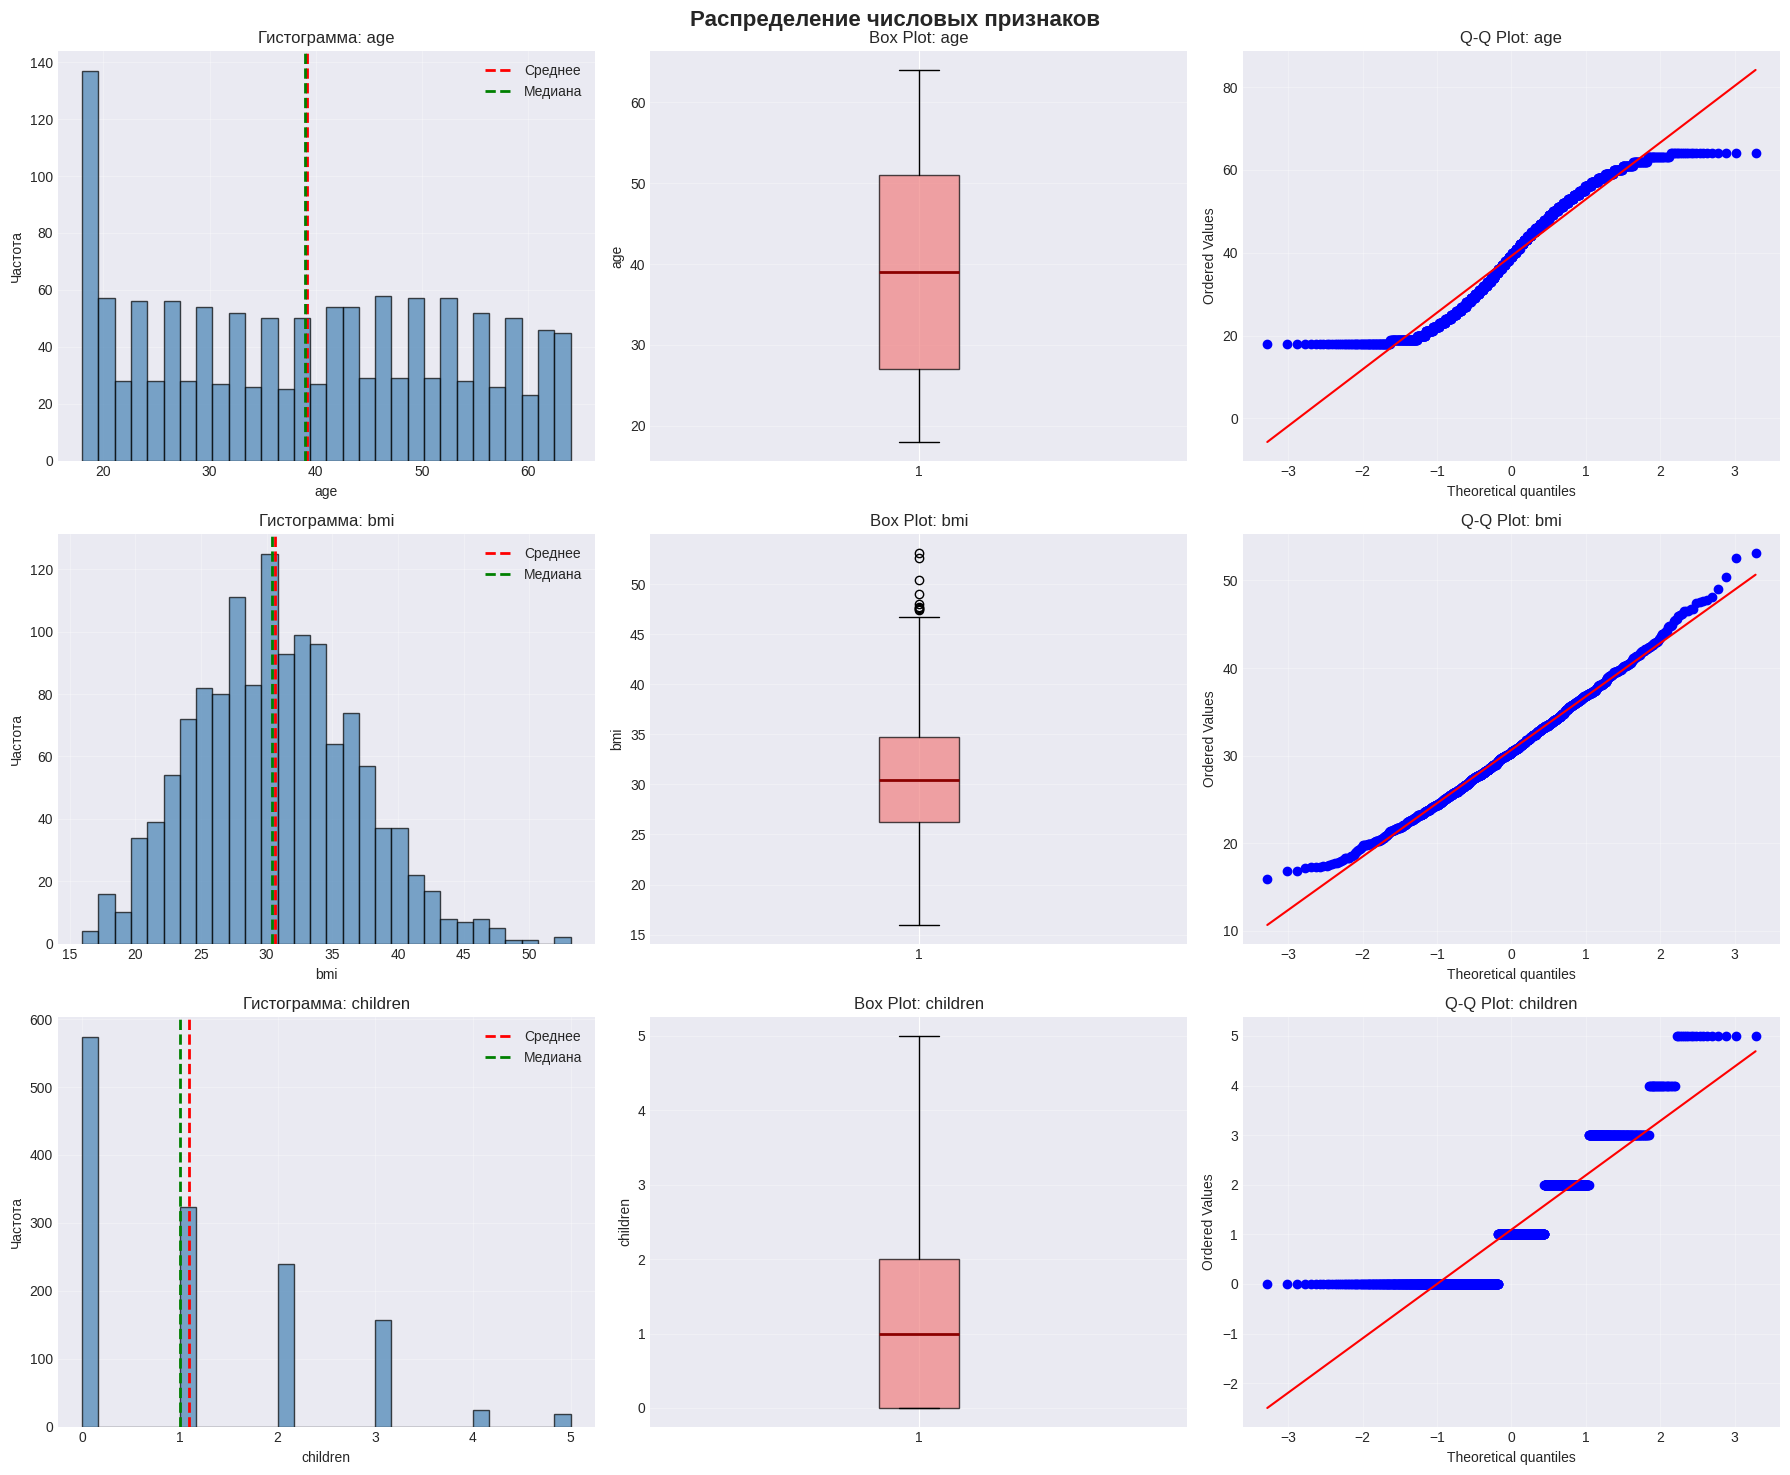

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Распределение числовых признаков', fontsize=16, fontweight='bold')

numeric_features = ['age', 'bmi', 'children']

for idx, feature in enumerate(numeric_features):
    # Гистограмма
    axes[idx, 0].hist(df[feature], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx, 0].axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label='Среднее')
    axes[idx, 0].axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, label='Медиана')
    axes[idx, 0].set_xlabel(feature)
    axes[idx, 0].set_ylabel('Частота')
    axes[idx, 0].set_title(f'Гистограмма: {feature}')
    axes[idx, 0].legend()
    axes[idx, 0].grid(True, alpha=0.3)

    # Box plot
    bp = axes[idx, 1].boxplot(df[feature], vert=True, patch_artist=True,
                               boxprops=dict(facecolor='lightcoral', alpha=0.7),
                               medianprops=dict(color='darkred', linewidth=2))
    axes[idx, 1].set_ylabel(feature)
    axes[idx, 1].set_title(f'Box Plot: {feature}')
    axes[idx, 1].grid(True, alpha=0.3, axis='y')

    # Q-Q plot
    stats.probplot(df[feature], dist="norm", plot=axes[idx, 2])
    axes[idx, 2].set_title(f'Q-Q Plot: {feature}')
    axes[idx, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Визуализация категориальных признаков

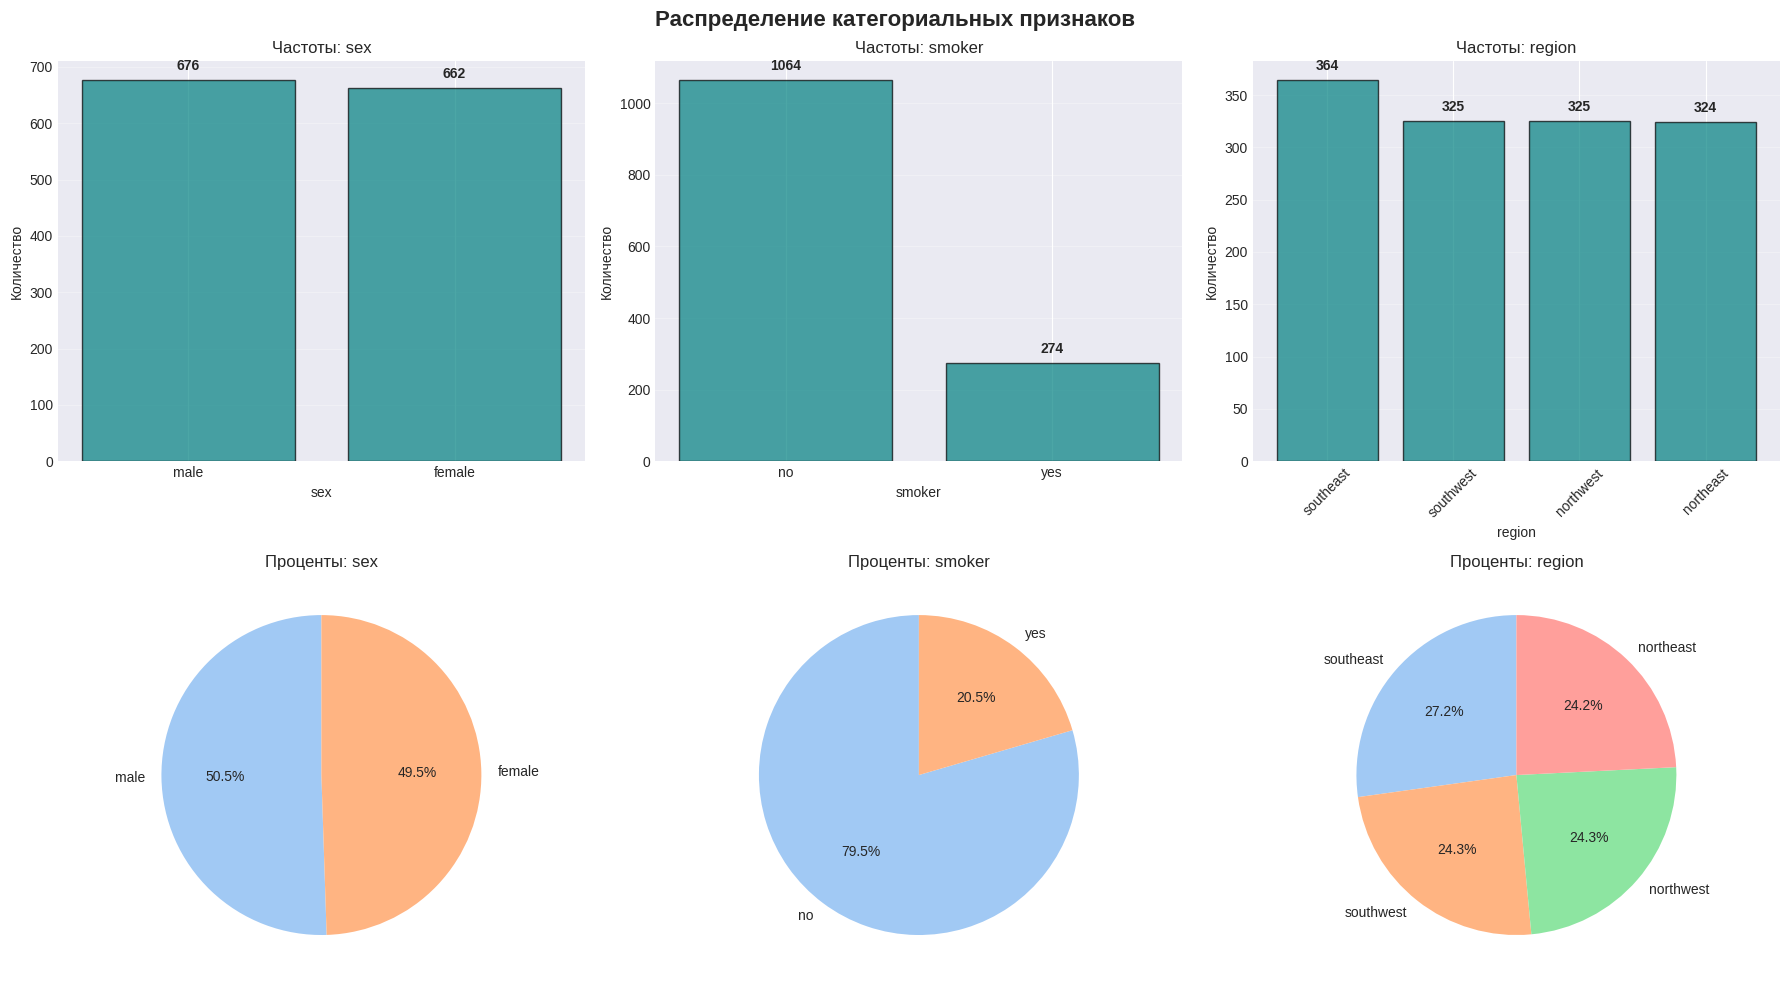

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold')

categorical_features = ['sex', 'smoker', 'region']

for idx, feature in enumerate(categorical_features):
    # Count plot
    value_counts = df[feature].value_counts()
    axes[0, idx].bar(value_counts.index, value_counts.values, alpha=0.7, color='teal', edgecolor='black')
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel('Количество')
    axes[0, idx].set_title(f'Частоты: {feature}')
    axes[0, idx].grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(value_counts.values):
        axes[0, idx].text(i, v + max(value_counts.values)*0.02, str(v), ha='center', va='bottom', fontweight='bold')
    if feature == 'region':
        axes[0, idx].tick_params(axis='x', rotation=45)

    # Pie chart
    axes[1, idx].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
                     startangle=90, colors=sns.color_palette('pastel'))
    axes[1, idx].set_title(f'Проценты: {feature}')

plt.tight_layout()
plt.show()

## 9. Корреляционный анализ

In [9]:
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ: Числовые признаки vs charges")
print("=" * 80)
print("H0: Корреляция = 0 | H1: Корреляция ≠ 0 | α = 0.05\n")

correlation_results = []

for feature in ['age', 'bmi', 'children']:
    # Pearson
    pearson_r, pearson_p = pearsonr(df[feature], df['charges'])
    # Spearman
    spearman_r, spearman_p = spearmanr(df[feature], df['charges'])

    print(f"{feature.upper()} vs CHARGES:")
    print(f"  Pearson:  r = {pearson_r:.4f}, p = {pearson_p:.4e} {'✓ Значимо' if pearson_p < 0.05 else '✗ Не значимо'}")
    print(f"  Spearman: ρ = {spearman_r:.4f}, p = {spearman_p:.4e} {'✓ Значимо' if spearman_p < 0.05 else '✗ Не значимо'}")

    if abs(pearson_r) < 0.3:
        strength = "слабая"
    elif abs(pearson_r) < 0.7:
        strength = "умеренная"
    else:
        strength = "сильная"
    direction = "положительная" if pearson_r > 0 else "отрицательная"
    print(f"  Интерпретация: {strength} {direction} связь\n")

    correlation_results.append({
        'Признак': feature,
        'Pearson r': f"{pearson_r:.4f}",
        'p-value': f"{pearson_p:.4e}",
        'Spearman ρ': f"{spearman_r:.4f}",
        'Сила связи': strength
    })

print("=" * 80)
corr_df = pd.DataFrame(correlation_results)
display(corr_df)

КОРРЕЛЯЦИОННЫЙ АНАЛИЗ: Числовые признаки vs charges
H0: Корреляция = 0 | H1: Корреляция ≠ 0 | α = 0.05

AGE vs CHARGES:
  Pearson:  r = 0.2990, p = 4.8867e-29 ✓ Значимо
  Spearman: ρ = 0.5344, p = 1.1307e-99 ✓ Значимо
  Интерпретация: слабая положительная связь

BMI vs CHARGES:
  Pearson:  r = 0.1983, p = 2.4591e-13 ✓ Значимо
  Spearman: ρ = 0.1194, p = 1.1926e-05 ✓ Значимо
  Интерпретация: слабая положительная связь

CHILDREN vs CHARGES:
  Pearson:  r = 0.0680, p = 1.2852e-02 ✓ Значимо
  Spearman: ρ = 0.1333, p = 9.8468e-07 ✓ Значимо
  Интерпретация: слабая положительная связь



,Признак,Pearson r,p-value,Spearman ρ,Сила связи
0,age,0.2990,4.8867e-29,0.5344,слабая
1,bmi,0.1983,2.4591e-13,0.1194,слабая
2,children,0.0680,1.2852e-02,0.1333,слабая


## 10. Корреляционные матрицы

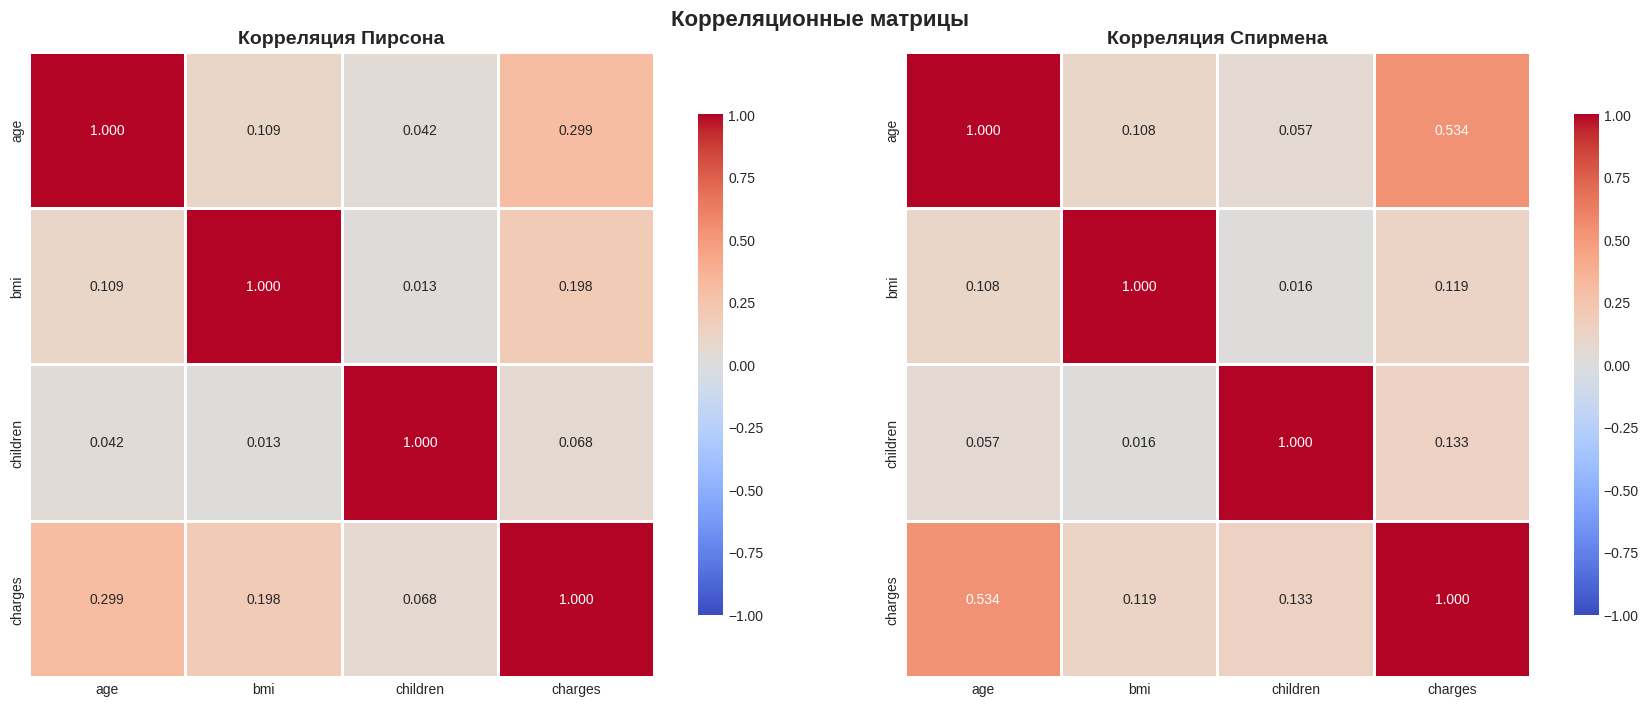

In [10]:
numeric_df = df[['age', 'bmi', 'children', 'charges']].copy()
numeric_df = numeric_df.select_dtypes(include='number')

corr_pearson = numeric_df.corr(method='pearson')
corr_spearman = numeric_df.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Корреляционные матрицы', fontsize=16, fontweight='bold')

# Pearson
sns.heatmap(corr_pearson, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[0],
            vmin=-1, vmax=1)
axes[0].set_title('Корреляция Пирсона', fontsize=14, fontweight='bold')

# Spearman
sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=axes[1],
            vmin=-1, vmax=1)
axes[1].set_title('Корреляция Спирмена', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
## 11. Анализ категориальных признаков vs charges

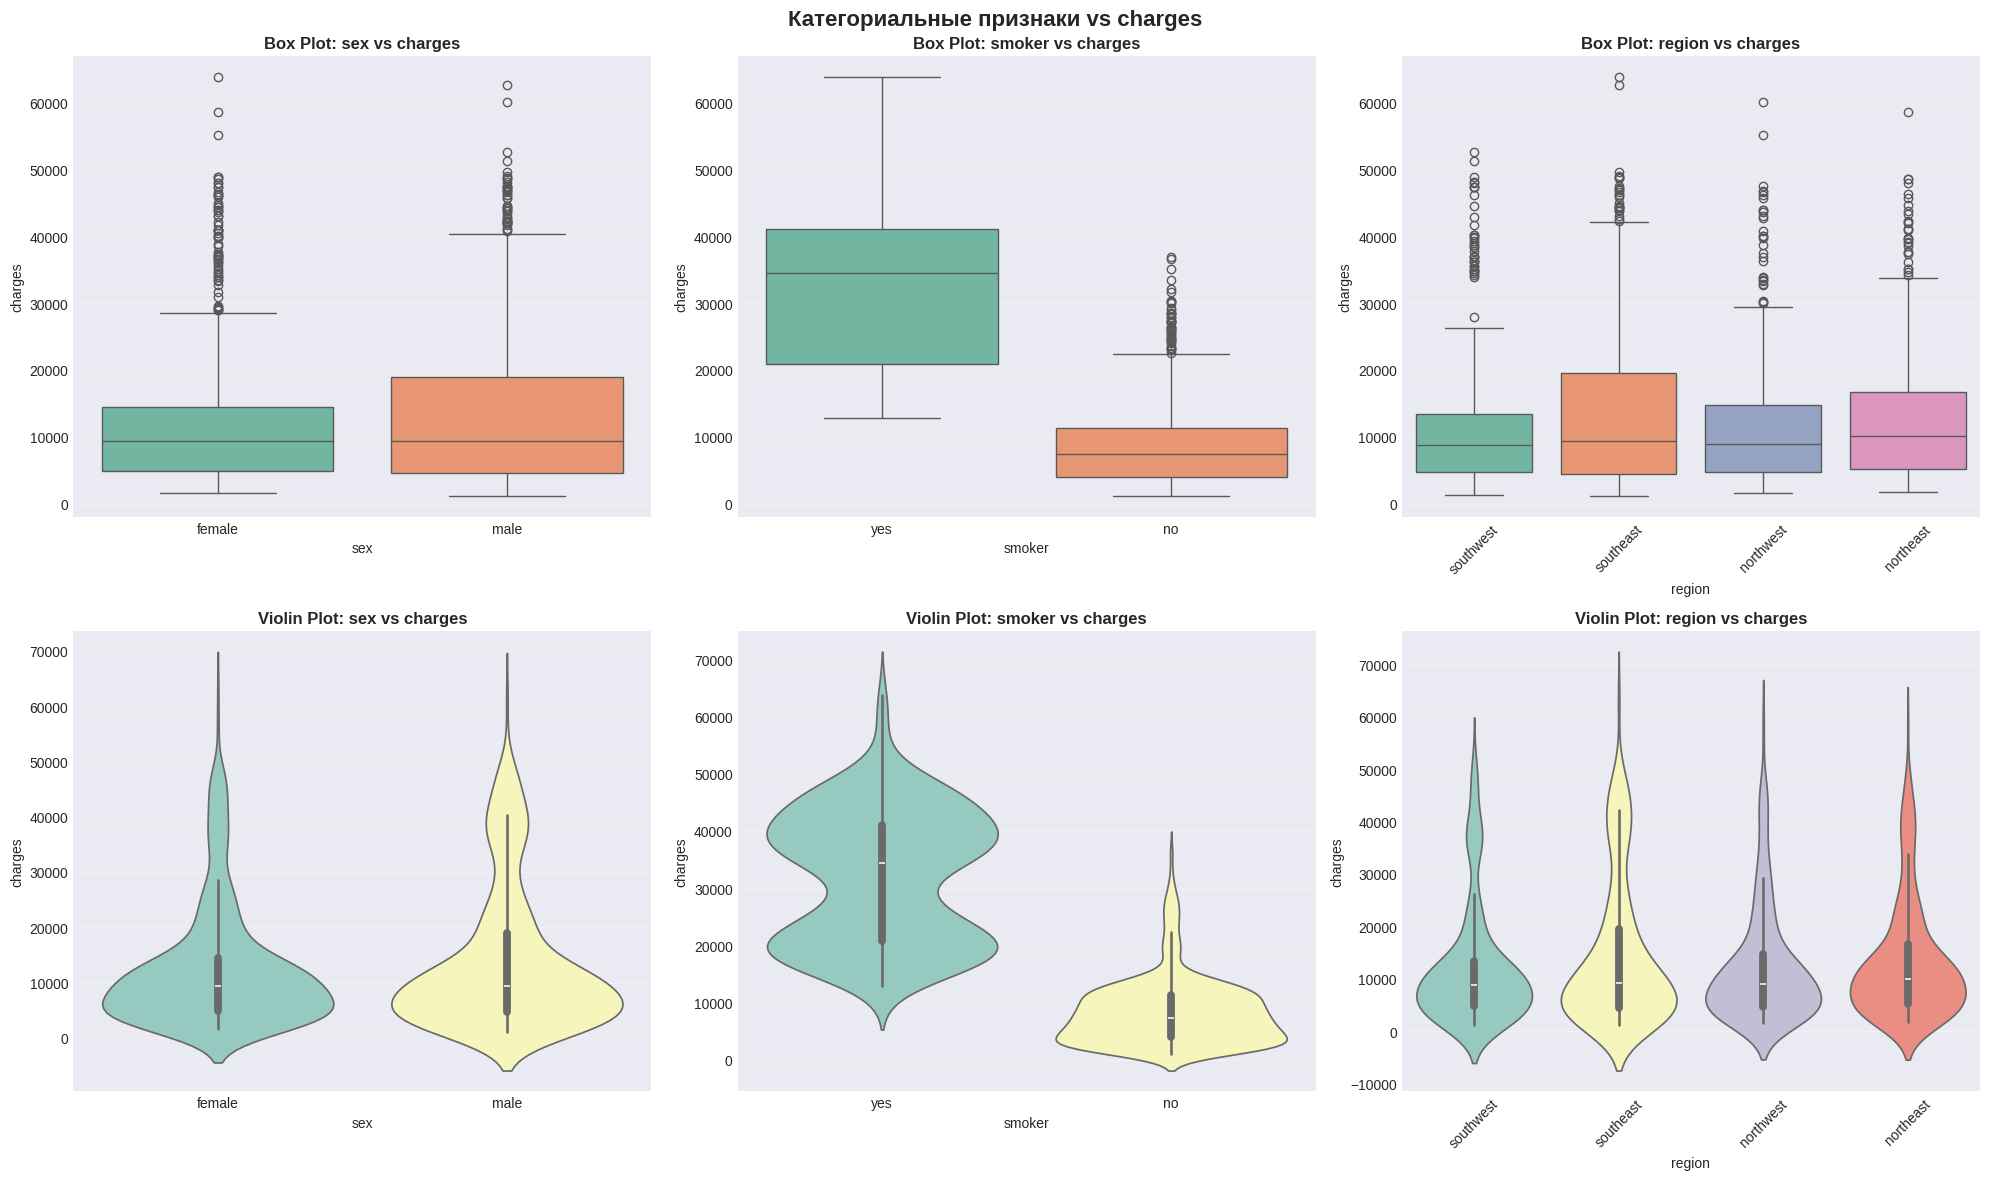

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Категориальные признаки vs charges', fontsize=16, fontweight='bold')

for idx, feature in enumerate(['sex', 'smoker', 'region']):
    # Box plot
    sns.boxplot(data=df, x=feature, y='charges', ax=axes[0, idx], palette='Set2')
    axes[0, idx].set_title(f'Box Plot: {feature} vs charges', fontweight='bold')
    axes[0, idx].set_xlabel(feature)
    axes[0, idx].set_ylabel('charges')
    axes[0, idx].grid(True, alpha=0.3, axis='y')
    if feature == 'region':
        axes[0, idx].tick_params(axis='x', rotation=45)

    # Violin plot
    sns.violinplot(data=df, x=feature, y='charges', ax=axes[1, idx], palette='Set3')
    axes[1, idx].set_title(f'Violin Plot: {feature} vs charges', fontweight='bold')
    axes[1, idx].set_xlabel(feature)
    axes[1, idx].set_ylabel('charges')
    axes[1, idx].grid(True, alpha=0.3, axis='y')
    if feature == 'region':
        axes[1, idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 12. Статистические тесты различий между группами

In [13]:
print("СТАТИСТИЧЕСКИЕ ТЕСТЫ: Категориальные признаки vs charges")

print("α = 0.05 | Если p < 0.05, отвергаем H0 (есть различия)\n")

# 1. SEX vs CHARGES
print("1. SEX vs CHARGES")

print("H0: Средняя стоимость одинакова для мужчин и женщин\n")

male_charges = df[df['sex'] == 'male']['charges']
female_charges = df[df['sex'] == 'female']['charges']

t_stat, t_p = ttest_ind(male_charges, female_charges)
u_stat, u_p = mannwhitneyu(male_charges, female_charges, alternative='two-sided')

print(f"t-test: статистика = {t_stat:.4f}, p = {t_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if t_p < 0.05 else 'Не отвергаем H0 - нет различий'}")
print(f"\nMann-Whitney U: статистика = {u_stat:.4f}, p = {u_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if u_p < 0.05 else 'Не отвергаем H0 - нет различий'}")
print(f"\nСредние: Male ${male_charges.mean():.2f}, Female ${female_charges.mean():.2f}")
print(f"Разница: ${abs(male_charges.mean() - female_charges.mean()):.2f}\n")

# 2. SMOKER vs CHARGES
print("\n2. SMOKER vs CHARGES")
print("H0: Средняя стоимость одинакова для курящих и некурящих\n")

smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

t_stat, t_p = ttest_ind(smoker_charges, nonsmoker_charges)
u_stat, u_p = mannwhitneyu(smoker_charges, nonsmoker_charges, alternative='two-sided')

print(f"t-test: статистика = {t_stat:.4f}, p = {t_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if t_p < 0.05 else 'Не отвергаем H0 - нет различий'}")
print(f"\nMann-Whitney U: статистика = {u_stat:.4f}, p = {u_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if u_p < 0.05 else 'Не отвергаем H0 - нет различий'}")
print(f"\nСредние: Smoker ${smoker_charges.mean():.2f}, Non-smoker ${nonsmoker_charges.mean():.2f}")
print(f"Разница: ${abs(smoker_charges.mean() - nonsmoker_charges.mean()):.2f}")
print(f"Кратность: {smoker_charges.mean() / nonsmoker_charges.mean():.2f}x\n")

# 3. REGION vs CHARGES
print("\n3. REGION vs CHARGES")

print("H0: Средняя стоимость одинакова во всех регионах\n")

regions = df['region'].unique()
region_groups = [df[df['region'] == region]['charges'] for region in regions]

f_stat, f_p = f_oneway(*region_groups)
h_stat, h_p = kruskal(*region_groups)

print(f"ANOVA: F = {f_stat:.4f}, p = {f_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if f_p < 0.05 else 'Не отвергаем H0 - нет различий'}")
print(f"\nKruskal-Wallis: H = {h_stat:.4f}, p = {h_p:.4e}")
print(f"  Вывод: {'Отвергаем H0 - есть различия' if h_p < 0.05 else 'Не отвергаем H0 - нет различий'}")

print(f"\nСредние по регионам:")
for region in regions:
    region_data = df[df['region'] == region]['charges']
    print(f"  {region}: ${region_data.mean():.2f} (n={len(region_data)})")

СТАТИСТИЧЕСКИЕ ТЕСТЫ: Категориальные признаки vs charges
α = 0.05 | Если p < 0.05, отвергаем H0 (есть различия)

1. SEX vs CHARGES
H0: Средняя стоимость одинакова для мужчин и женщин

t-test: статистика = 2.0975, p = 3.6133e-02
  Вывод: Отвергаем H0 - есть различия

Mann-Whitney U: статистика = 226208.0000, p = 7.2865e-01
  Вывод: Не отвергаем H0 - нет различий

Средние: Male $13956.75, Female $12569.58
Разница: $1387.17


2. SMOKER vs CHARGES
H0: Средняя стоимость одинакова для курящих и некурящих

t-test: статистика = 46.6649, p = 8.2714e-283
  Вывод: Отвергаем H0 - есть различия

Mann-Whitney U: статистика = 284133.0000, p = 5.2702e-130
  Вывод: Отвергаем H0 - есть различия

Средние: Smoker $32050.23, Non-smoker $8434.27
Разница: $23615.96
Кратность: 3.80x


3. REGION vs CHARGES
H0: Средняя стоимость одинакова во всех регионах

ANOVA: F = 2.9696, p = 3.0893e-02
  Вывод: Отвергаем H0 - есть различия

Kruskal-Wallis: H = 4.7342, p = 1.9233e-01
  Вывод: Не отвергаем H0 - нет различий



## 13. Кодирование категориальных признаков

In [14]:
# Создаем копию для обработки
df_processed = df.copy()

print("КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ")
print("=" * 80)

# Sex: male=1, female=0
df_processed['sex_encoded'] = (df_processed['sex'] == 'male').astype(int)
print("\n1. SEX (Label Encoding):")
print("   male → 1, female → 0")

# Smoker: yes=1, no=0
df_processed['smoker_encoded'] = (df_processed['smoker'] == 'yes').astype(int)
print("\n2. SMOKER (Label Encoding):")
print("   yes → 1, no → 0")

# One-Hot Encoding для region
region_dummies = pd.get_dummies(df_processed['region'], prefix='region', drop_first=True)
df_processed = pd.concat([df_processed, region_dummies], axis=1)

print("\n3. REGION (One-Hot Encoding, drop_first=True):")
print(f"   Созданные признаки: {list(region_dummies.columns)}")
print("   (region_northeast опущен как базовый)")

# Удаляем исходные категориальные столбцы
df_processed = df_processed.drop(['sex', 'smoker', 'region'], axis=1)

print(f"\n✓ Кодирование завершено")
print(f"Итоговые столбцы ({len(df_processed.columns)}): {list(df_processed.columns)}")
display(df_processed.head())

КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ

1. SEX (Label Encoding):
   male → 1, female → 0

2. SMOKER (Label Encoding):
   yes → 1, no → 0

3. REGION (One-Hot Encoding, drop_first=True):
   Созданные признаки: ['region_northwest', 'region_southeast', 'region_southwest']
   (region_northeast опущен как базовый)

✓ Кодирование завершено
Итоговые столбцы (9): ['age', 'bmi', 'children', 'charges', 'sex_encoded', 'smoker_encoded', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,False,False,True
1,18,33.770,1,1725.55230,1,0,False,True,False
2,28,33.000,3,4449.46200,1,0,False,True,False
3,33,22.705,0,21984.47061,1,0,True,False,False
4,32,28.880,0,3866.85520,1,0,True,False,False


## 14. Feature Engineering

In [15]:
print("FEATURE ENGINEERING")

# 1. Возрастные группы
df_processed['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 65], labels=[0, 1, 2])
df_processed['age_group'] = df_processed['age_group'].astype(int)
print("\n1. AGE_GROUP:")
print("   0: 18-30 лет (молодые)")
print("   1: 31-45 лет (средний возраст)")
print("   2: 46-64 лет (старшие)")

# 2. Категории BMI
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 0  # Недовес
    elif bmi < 25:
        return 1  # Норма
    elif bmi < 30:
        return 2  # Избыточный вес
    else:
        return 3  # Ожирение

df_processed['bmi_category'] = df['bmi'].apply(categorize_bmi)
print("\n2. BMI_CATEGORY:")
print("   0: < 18.5 (недовес)")
print("   1: 18.5-24.9 (норма)")
print("   2: 25-29.9 (избыточный вес)")
print("   3: ≥ 30 (ожирение)")

# 3. Взаимодействия
df_processed['smoker_bmi'] = df_processed['smoker_encoded'] * df['bmi']
df_processed['age_smoker'] = df['age'] * df_processed['smoker_encoded']
df_processed['age_bmi'] = df['age'] * df['bmi']

print("\n3. INTERACTION FEATURES:")
print("   • smoker_bmi = smoker × bmi")
print("   • age_smoker = age × smoker")
print("   • age_bmi = age × bmi")

# 4. Полиномиальные признаки
df_processed['age_squared'] = df['age'] ** 2
df_processed['bmi_squared'] = df['bmi'] ** 2

print("\n4. POLYNOMIAL FEATURES:")
print("   • age_squared = age²")
print("   • bmi_squared = bmi²")

print(f"\n✓ Feature Engineering завершен")
print(f"Всего признаков: {df_processed.shape[1]}")
print(f"Новые признаки: {df_processed.shape[1] - df.shape[1]}")
display(df_processed.head())

FEATURE ENGINEERING

1. AGE_GROUP:
   0: 18-30 лет (молодые)
   1: 31-45 лет (средний возраст)
   2: 46-64 лет (старшие)

2. BMI_CATEGORY:
   0: < 18.5 (недовес)
   1: 18.5-24.9 (норма)
   2: 25-29.9 (избыточный вес)
   3: ≥ 30 (ожирение)

3. INTERACTION FEATURES:
   • smoker_bmi = smoker × bmi
   • age_smoker = age × smoker
   • age_bmi = age × bmi

4. POLYNOMIAL FEATURES:
   • age_squared = age²
   • bmi_squared = bmi²

✓ Feature Engineering завершен
Всего признаков: 16
Новые признаки: 9


,age,bmi,children,charges,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,age_group,bmi_category,smoker_bmi,age_smoker,age_bmi,age_squared,bmi_squared
0,19,27.900,0,16884.92400,0,1,False,False,True,0,2,27.9,19,530.100,361,778.410000
1,18,33.770,1,1725.55230,1,0,False,True,False,0,3,0.0,0,607.860,324,1140.412900
2,28,33.000,3,4449.46200,1,0,False,True,False,0,3,0.0,0,924.000,784,1089.000000
3,33,22.705,0,21984.47061,1,0,True,False,False,1,1,0.0,0,749.265,1089,515.517025
4,32,28.880,0,3866.85520,1,0,True,False,False,1,2,0.0,0,924.160,1024,834.054400


## 15. Проверка мультиколлинеарности (VIF)

In [16]:
print("ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF)")
print("VIF (Variance Inflation Factor) - фактор инфляции дисперсии")
print("VIF < 5: низкая мультиколлинеарность")
print("5 ≤ VIF < 10: умеренная мультиколлинеарность")
print("VIF ≥ 10: высокая мультиколлинеарность (проблема!)\n")

# Выбираем только числовые признаки для VIF
feature_cols = [col for col in df_processed.columns if col != 'charges']
X_for_vif = df_processed[feature_cols].copy()
X_for_vif = X_for_vif.astype(float)

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Признак"] = X_for_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_for_vif.values, i) for i in range(len(X_for_vif.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)

display(vif_data)

# Анализ
high_vif = vif_data[vif_data['VIF'] >= 10]
if len(high_vif) > 0:
    print(f"\n ВНИМАНИЕ! Обнаружено {len(high_vif)} признаков с высоким VIF (≥10):")
    for _, row in high_vif.iterrows():
        print(f"   • {row['Признак']}: VIF = {row['VIF']:.2f}")
    print("\nРекомендация: Рассмотреть удаление или преобразование этих признаков")
else:
    print("\n✓ Мультиколлинеарность в пределах нормы")

ПРОВЕРКА МУЛЬТИКОЛЛИНЕАРНОСТИ (VIF)
VIF (Variance Inflation Factor) - фактор инфляции дисперсии
VIF < 5: низкая мультиколлинеарность
5 ≤ VIF < 10: умеренная мультиколлинеарность
VIF ≥ 10: высокая мультиколлинеарность (проблема!)



,Признак,VIF
1,bmi,693.101879
0,age,670.507780
14,bmi_squared,276.397297
12,age_bmi,219.045935
13,age_squared,164.363362
9,bmi_category,39.529981
4,smoker_encoded,38.915036
10,smoker_bmi,31.914673
8,age_group,23.723998
11,age_smoker,10.962756



 ВНИМАНИЕ! Обнаружено 10 признаков с высоким VIF (≥10):
   • bmi: VIF = 693.10
   • age: VIF = 670.51
   • bmi_squared: VIF = 276.40
   • age_bmi: VIF = 219.05
   • age_squared: VIF = 164.36
   • bmi_category: VIF = 39.53
   • smoker_encoded: VIF = 38.92
   • smoker_bmi: VIF = 31.91
   • age_group: VIF = 23.72
   • age_smoker: VIF = 10.96

Рекомендация: Рассмотреть удаление или преобразование этих признаков


## 16. Разделение данных на train/test

In [17]:
print("РАЗДЕЛЕНИЕ ДАННЫХ")

# Признаки и целевая переменная
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

print(f"Признаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("РЕЗУЛЬТАТ РАЗДЕЛЕНИЯ:")

print(f"Обучающая выборка: {X_train.shape[0]} примеров ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Тестовая выборка:  {X_test.shape[0]} примеров ({X_test.shape[0]/len(df)*100:.1f}%)")
print(f"\nСтатистика целевой переменной:")
print(f"  Train - Среднее: ${y_train.mean():.2f}, Медиана: ${y_train.median():.2f}")
print(f"  Test  - Среднее: ${y_test.mean():.2f}, Медиана: ${y_test.median():.2f}")

РАЗДЕЛЕНИЕ ДАННЫХ
Признаки (X): (1338, 15)
Целевая переменная (y): (1338,)
РЕЗУЛЬТАТ РАЗДЕЛЕНИЯ:
Обучающая выборка: 1070 примеров (80.0%)
Тестовая выборка:  268 примеров (20.0%)

Статистика целевой переменной:
  Train - Среднее: $13346.09, Медиана: $9575.44
  Test  - Среднее: $12968.32, Медиана: $8487.88


## 17. Масштабирование признаков

In [18]:
print("МАСШТАБИРОВАНИЕ ПРИЗНАКОВ")

# Создаем scaler
scaler = StandardScaler()

# Обучаем scaler только на train данных
scaler.fit(X_train)

# Применяем к train и test
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Преобразуем обратно в DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("✓ Масштабирование завершено")
print(f"\nПример масштабированных данных (первые 5 строк):")
display(X_train_scaled.head())

МАСШТАБИРОВАНИЕ ПРИЗНАКОВ
✓ Масштабирование завершено

Пример масштабированных данных (первые 5 строк):


,age,bmi,children,sex_encoded,smoker_encoded,region_northwest,region_southeast,region_southwest,age_group,bmi_category,smoker_bmi,age_smoker,age_bmi,age_squared,bmi_squared
560,0.472227,-1.756525,0.734336,-1.024602,-0.508747,1.783168,-0.599661,-0.572314,1.130549,-1.645605,-0.495987,-0.470101,-0.562736,0.327869,-1.497631
1285,0.543313,-1.033082,-0.911192,-1.024602,-0.508747,-0.560800,-0.599661,-0.572314,1.130549,-1.645605,-0.495987,-0.470101,-0.133051,0.410473,-0.991482
1142,0.898745,-0.943687,-0.911192,-1.024602,-0.508747,-0.560800,1.667609,-0.572314,1.130549,-1.645605,-0.495987,-0.470101,0.152363,0.850137,-0.922001
969,-0.025379,0.622393,3.202629,-1.024602,-0.508747,-0.560800,1.667609,-0.572314,-0.064794,0.846677,-0.495987,-0.470101,0.239620,-0.200616,0.542715
486,1.040918,-1.504893,1.557100,-1.024602,-0.508747,1.783168,-0.599661,-0.572314,1.130549,-1.645605,-0.495987,-0.470101,-0.101894,1.038438,-1.332913


## 18. Функции для оценки моделей

In [19]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """Полная оценка модели на train и test"""
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Метрики на train
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)

    # Метрики на test
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Вывод результатов
    print(f"\n{'='*80}")
    print(f"{model_name}")

    print(f"\nTRAIN SET:")
    print(f"  R²:   {train_r2:.4f}")
    print(f"  RMSE: ${train_rmse:,.2f}")
    print(f"  MAE:  ${train_mae:,.2f}")

    print(f"\nTEST SET:")
    print(f"  R²:   {test_r2:.4f}")
    print(f"  RMSE: ${test_rmse:,.2f}")
    print(f"  MAE:  ${test_mae:,.2f}")

    # Проверка на переобучение
    overfit = train_r2 - test_r2
    print(f"\nПереобучение (Train R² - Test R²): {overfit:.4f}")
    if overfit > 0.1:
        print("  ⚠ ВНИМАНИЕ: Возможно переобучение!")
    elif overfit < 0:
        print("  ✓ Модель хорошо генерализует")
    else:
        print("  ✓ Переобучение в пределах нормы")

    return {
        'model_name': model_name,
        'train_r2': train_r2,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'test_r2': test_r2,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'overfit': overfit
    }

def cross_validate_model(model, X, y, cv=5, model_name="Model"):
    """Кросс-валидация модели"""
    print(f"\nКросс-валидация ({cv}-fold): {model_name}")
    print("-" * 40)

    r2_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
    mse_scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(mse_scores)

    print(f"  R² scores: {r2_scores}")
    print(f"  Среднее R²: {r2_scores.mean():.4f} (±{r2_scores.std():.4f})")
    print(f"  RMSE scores: {rmse_scores}")
    print(f"  Среднее RMSE: ${rmse_scores.mean():,.2f} (±${rmse_scores.std():,.2f})")

    return r2_scores.mean(), rmse_scores.mean()

print("✓ Функции оценки моделей определены")

✓ Функции оценки моделей определены


## 19. Baseline модель - Linear Regression

In [20]:

print("BASELINE МОДЕЛЬ: LINEAR REGRESSION")

print("\nПростая линейная регрессия без регуляризации\n")

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_results = evaluate_model(
    baseline_model, X_train, X_test, y_train, y_test,
    model_name="BASELINE: Linear Regression"
)

baseline_cv_r2, baseline_cv_rmse = cross_validate_model(
    baseline_model, X_train, y_train, cv=5,
    model_name="Linear Regression"
)


print("АНАЛИЗ КОЭФФИЦИЕНТОВ (топ-10 по важности)")


coefficients = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': baseline_model.coef_,
    'Абс.значение': np.abs(baseline_model.coef_)
}).sort_values('Абс.значение', ascending=False)

display(coefficients.head(10))

print(f"\nСвободный член (intercept): ${baseline_model.intercept_:,.2f}")

BASELINE МОДЕЛЬ: LINEAR REGRESSION

Простая линейная регрессия без регуляризации


BASELINE: Linear Regression

TRAIN SET:
  R²:   0.8399
  RMSE: $4,807.74
  MAE:  $2,880.71

TEST SET:
  R²:   0.8682
  RMSE: $4,523.36
  MAE:  $2,708.14

Переобучение (Train R² - Test R²): -0.0284
  ✓ Модель хорошо генерализует

Кросс-валидация (5-fold): Linear Regression
----------------------------------------
  R² scores: [0.81963    0.90048323 0.81129861 0.76532927 0.85985561]
  Среднее R²: 0.8313 (±0.0458)
  RMSE scores: [5047.26781498 4016.32202138 4945.68120851 5652.82135032 4588.07244767]
  Среднее RMSE: $4,850.03 (±$539.67)
АНАЛИЗ КОЭФФИЦИЕНТОВ (топ-10 по важности)


,Признак,Коэффициент,Абс.значение
4,smoker_encoded,-21120.503173,21120.503173
9,bmi_category,1735.870701,1735.870701
10,smoker_bmi,1465.772288,1465.772288
7,region_southwest,-1246.089518,1246.089518
6,region_southeast,-843.743643,843.743643
5,region_northwest,-716.658354,716.658354
2,children,617.824394,617.824394
8,age_group,-545.041098,545.041098
3,sex_encoded,-525.904535,525.904535
1,bmi,-354.925270,354.925270



Свободный член (intercept): $7,482.04


## 20. Ridge Regression

In [21]:

print("МОДЕЛЬ 2: RIDGE REGRESSION (L2)")


ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

param_grid_ridge = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV...")
ridge_grid.fit(X_train, y_train)

print(f"\n✓ Поиск завершен!")
print(f"Лучшие параметры: {ridge_grid.best_params_}")
print(f"Лучший R² (CV): {ridge_grid.best_score_:.4f}")

ridge_results = evaluate_model(
    ridge_grid.best_estimator_, X_train, X_test, y_train, y_test,
    model_name="RIDGE REGRESSION (оптимизированная)"
)


print("РЕЗУЛЬТАТЫ GRID SEARCH")

results_df = pd.DataFrame(ridge_grid.cv_results_)
results_summary = results_df[['param_ridge__alpha', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False)
results_summary.columns = ['Alpha', 'Mean R²', 'Std R²']
display(results_summary)

МОДЕЛЬ 2: RIDGE REGRESSION (L2)
Запуск GridSearchCV...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✓ Поиск завершен!
Лучшие параметры: {'ridge__alpha': 1}
Лучший R² (CV): 0.8314

RIDGE REGRESSION (оптимизированная)

TRAIN SET:
  R²:   0.8397
  RMSE: $4,809.49
  MAE:  $2,884.50

TEST SET:
  R²:   0.8686
  RMSE: $4,516.15
  MAE:  $2,719.15

Переобучение (Train R² - Test R²): -0.0289
  ✓ Модель хорошо генерализует
РЕЗУЛЬТАТЫ GRID SEARCH


,Alpha,Mean R²,Std R²
3,1.000,0.831441,0.045827
2,0.100,0.831356,0.045807
1,0.010,0.831323,0.045805
0,0.001,0.831320,0.045804
4,10.000,0.824887,0.045964
5,100.000,0.788523,0.046672
6,1000.000,0.706710,0.036699


## 21. Lasso Regression

In [22]:
print("МОДЕЛЬ 3: LASSO REGRESSION (L1)")

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid_lasso,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV...")
lasso_grid.fit(X_train, y_train)

print(f"\n✓ Поиск завершен!")
print(f"Лучшие параметры: {lasso_grid.best_params_}")
print(f"Лучший R² (CV): {lasso_grid.best_score_:.4f}")

lasso_results = evaluate_model(
    lasso_grid.best_estimator_, X_train, X_test, y_train, y_test,
    model_name="LASSO REGRESSION (оптимизированная)"
)

# Анализ отобранных признаков
lasso_model = lasso_grid.best_estimator_.named_steps['lasso']
lasso_coefs = pd.DataFrame({
    'Признак': X_train.columns,
    'Коэффициент': lasso_model.coef_
})
non_zero = lasso_coefs[lasso_coefs['Коэффициент'] != 0]
zero_coefs = lasso_coefs[lasso_coefs['Коэффициент'] == 0]

print("ОТБОР ПРИЗНАКОВ (LASSO)")

print(f"Признаков с ненулевыми коэффициентами: {len(non_zero)}")
print(f"Признаков с нулевыми коэффициентами: {len(zero_coefs)}")
if len(zero_coefs) > 0:
    print(f"\nОбнуленные признаки: {list(zero_coefs['Признак'].values)}")

МОДЕЛЬ 3: LASSO REGRESSION (L1)
Запуск GridSearchCV...
Fitting 5 folds for each of 7 candidates, totalling 35 fits

✓ Поиск завершен!
Лучшие параметры: {'lasso__alpha': 10}
Лучший R² (CV): 0.8319

LASSO REGRESSION (оптимизированная)

TRAIN SET:
  R²:   0.8397
  RMSE: $4,810.32
  MAE:  $2,886.63

TEST SET:
  R²:   0.8687
  RMSE: $4,515.58
  MAE:  $2,715.63

Переобучение (Train R² - Test R²): -0.0290
  ✓ Модель хорошо генерализует
ОТБОР ПРИЗНАКОВ (LASSO)
Признаков с ненулевыми коэффициентами: 12
Признаков с нулевыми коэффициентами: 3

Обнуленные признаки: ['age', 'age_smoker', 'bmi_squared']


## 22. ElasticNet

In [23]:
print("МОДЕЛЬ 4: ELASTICNET (L1 + L2)")


elasticnet_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('elasticnet', ElasticNet(max_iter=10000))
])

param_grid_elasticnet = {
    'elasticnet__alpha': [0.001, 0.01, 0.1, 1, 10],
    'elasticnet__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elasticnet_grid = GridSearchCV(
    elasticnet_pipeline,
    param_grid_elasticnet,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV...")
elasticnet_grid.fit(X_train, y_train)

print(f"\n✓ Поиск завершен!")
print(f"Лучшие параметры: {elasticnet_grid.best_params_}")
print(f"Лучший R² (CV): {elasticnet_grid.best_score_:.4f}")

elasticnet_results = evaluate_model(
    elasticnet_grid.best_estimator_, X_train, X_test, y_train, y_test,
    model_name="ELASTICNET (оптимизированная)"
)

МОДЕЛЬ 4: ELASTICNET (L1 + L2)
Запуск GridSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✓ Поиск завершен!
Лучшие параметры: {'elasticnet__alpha': 0.001, 'elasticnet__l1_ratio': 0.1}
Лучший R² (CV): 0.8315

ELASTICNET (оптимизированная)

TRAIN SET:
  R²:   0.8397
  RMSE: $4,809.37
  MAE:  $2,884.34

TEST SET:
  R²:   0.8686
  RMSE: $4,516.31
  MAE:  $2,718.72

Переобучение (Train R² - Test R²): -0.0289
  ✓ Модель хорошо генерализует


## 23. Random Forest Regressor

In [24]:
print("МОДЕЛЬ 5: RANDOM FOREST REGRESSOR")


rf_model = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV (может занять время)...")
rf_grid.fit(X_train, y_train)

print(f"\n✓ Поиск завершен!")
print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший R² (CV): {rf_grid.best_score_:.4f}")

rf_results = evaluate_model(
    rf_grid.best_estimator_, X_train, X_test, y_train, y_test,
    model_name="RANDOM FOREST (оптимизированная)"
)

# Feature importance
feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': rf_grid.best_estimator_.feature_importances_
}).sort_values('Важность', ascending=False)


print("ВАЖНОСТЬ ПРИЗНАКОВ (топ-10)")

display(feature_importance.head(10))

МОДЕЛЬ 5: RANDOM FOREST REGRESSOR
Запуск GridSearchCV (может занять время)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✓ Поиск завершен!
Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Лучший R² (CV): 0.8402

RANDOM FOREST (оптимизированная)

TRAIN SET:
  R²:   0.9069
  RMSE: $3,665.20
  MAE:  $2,021.66

TEST SET:
  R²:   0.8732
  RMSE: $4,437.67
  MAE:  $2,468.88

Переобучение (Train R² - Test R²): 0.0338
  ✓ Переобучение в пределах нормы
ВАЖНОСТЬ ПРИЗНАКОВ (топ-10)


,Признак,Важность
10,smoker_bmi,0.813210
0,age,0.048480
13,age_squared,0.047464
12,age_bmi,0.041728
11,age_smoker,0.011322
2,children,0.010948
1,bmi,0.007684
14,bmi_squared,0.007074
4,smoker_encoded,0.003901
3,sex_encoded,0.001856


## 24. Gradient Boosting Regressor

In [25]:
print("МОДЕЛЬ 6: GRADIENT BOOSTING REGRESSOR")


gb_model = GradientBoostingRegressor(random_state=42)

param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

gb_grid = GridSearchCV(
    gb_model,
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("Запуск GridSearchCV (может занять время)...")
gb_grid.fit(X_train, y_train)

print(f"\n✓ Поиск завершен!")
print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший R² (CV): {gb_grid.best_score_:.4f}")

gb_results = evaluate_model(
    gb_grid.best_estimator_, X_train, X_test, y_train, y_test,
    model_name="GRADIENT BOOSTING (оптимизированная)"
)

gb_feature_importance = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': gb_grid.best_estimator_.feature_importances_
}).sort_values('Важность', ascending=False)


print("ВАЖНОСТЬ ПРИЗНАКОВ (топ-10)")

display(gb_feature_importance.head(10))

МОДЕЛЬ 6: GRADIENT BOOSTING REGRESSOR
Запуск GridSearchCV (может занять время)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✓ Поиск завершен!
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Лучший R² (CV): 0.8486

GRADIENT BOOSTING (оптимизированная)

TRAIN SET:
  R²:   0.8708
  RMSE: $4,319.06
  MAE:  $2,528.65

TEST SET:
  R²:   0.8718
  RMSE: $4,460.66
  MAE:  $2,679.81

Переобучение (Train R² - Test R²): -0.0011
  ✓ Модель хорошо генерализует
ВАЖНОСТЬ ПРИЗНАКОВ (топ-10)


,Признак,Важность
10,smoker_bmi,0.816451
0,age,0.046624
13,age_squared,0.035601
12,age_bmi,0.033550
11,age_smoker,0.028387
4,smoker_encoded,0.017600
1,bmi,0.005849
2,children,0.005754
14,bmi_squared,0.004898
9,bmi_category,0.004578


## 25. Сравнение всех моделей

In [26]:
print("СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")


all_results = pd.DataFrame([
    baseline_results,
    ridge_results,
    lasso_results,
    elasticnet_results,
    rf_results,
    gb_results
])

all_results = all_results.sort_values('test_r2', ascending=False)

display_results = all_results[['model_name', 'test_r2', 'test_rmse', 'test_mae', 'overfit']].copy()
display_results.columns = ['Модель', 'Test R²', 'Test RMSE ($)', 'Test MAE ($)', 'Переобучение']
display_results = display_results.reset_index(drop=True)

print("\nРезультаты на тестовой выборке (отсортировано по R²):")
display(display_results)

best_model_name = all_results.iloc[0]['model_name']
best_r2 = all_results.iloc[0]['test_r2']
best_rmse = all_results.iloc[0]['test_rmse']


print(f"🏆 ЛУЧШАЯ МОДЕЛЬ: {best_model_name}")

print(f"Test R²:   {best_r2:.4f}")
print(f"Test RMSE: ${best_rmse:,.2f}")

СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ

Результаты на тестовой выборке (отсортировано по R²):


,Модель,Test R²,Test RMSE ($),Test MAE ($),Переобучение
0,RANDOM FOREST (оптимизированная),0.873152,4437.673450,2468.881155,0.033774
1,GRADIENT BOOSTING (оптимизированная),0.871835,4460.663085,2679.808068,-0.001079
2,LASSO REGRESSION (оптимизированная),0.868659,4515.581474,2715.626863,-0.028977
3,RIDGE REGRESSION (оптимизированная),0.868626,4516.148230,2719.152935,-0.028888
4,ELASTICNET (оптимизированная),0.868617,4516.313588,2718.715496,-0.028870
5,BASELINE: Linear Regression,0.868207,4523.357277,2708.142602,-0.028352


🏆 ЛУЧШАЯ МОДЕЛЬ: RANDOM FOREST (оптимизированная)
Test R²:   0.8732
Test RMSE: $4,437.67


## 26. Визуализация сравнения моделей

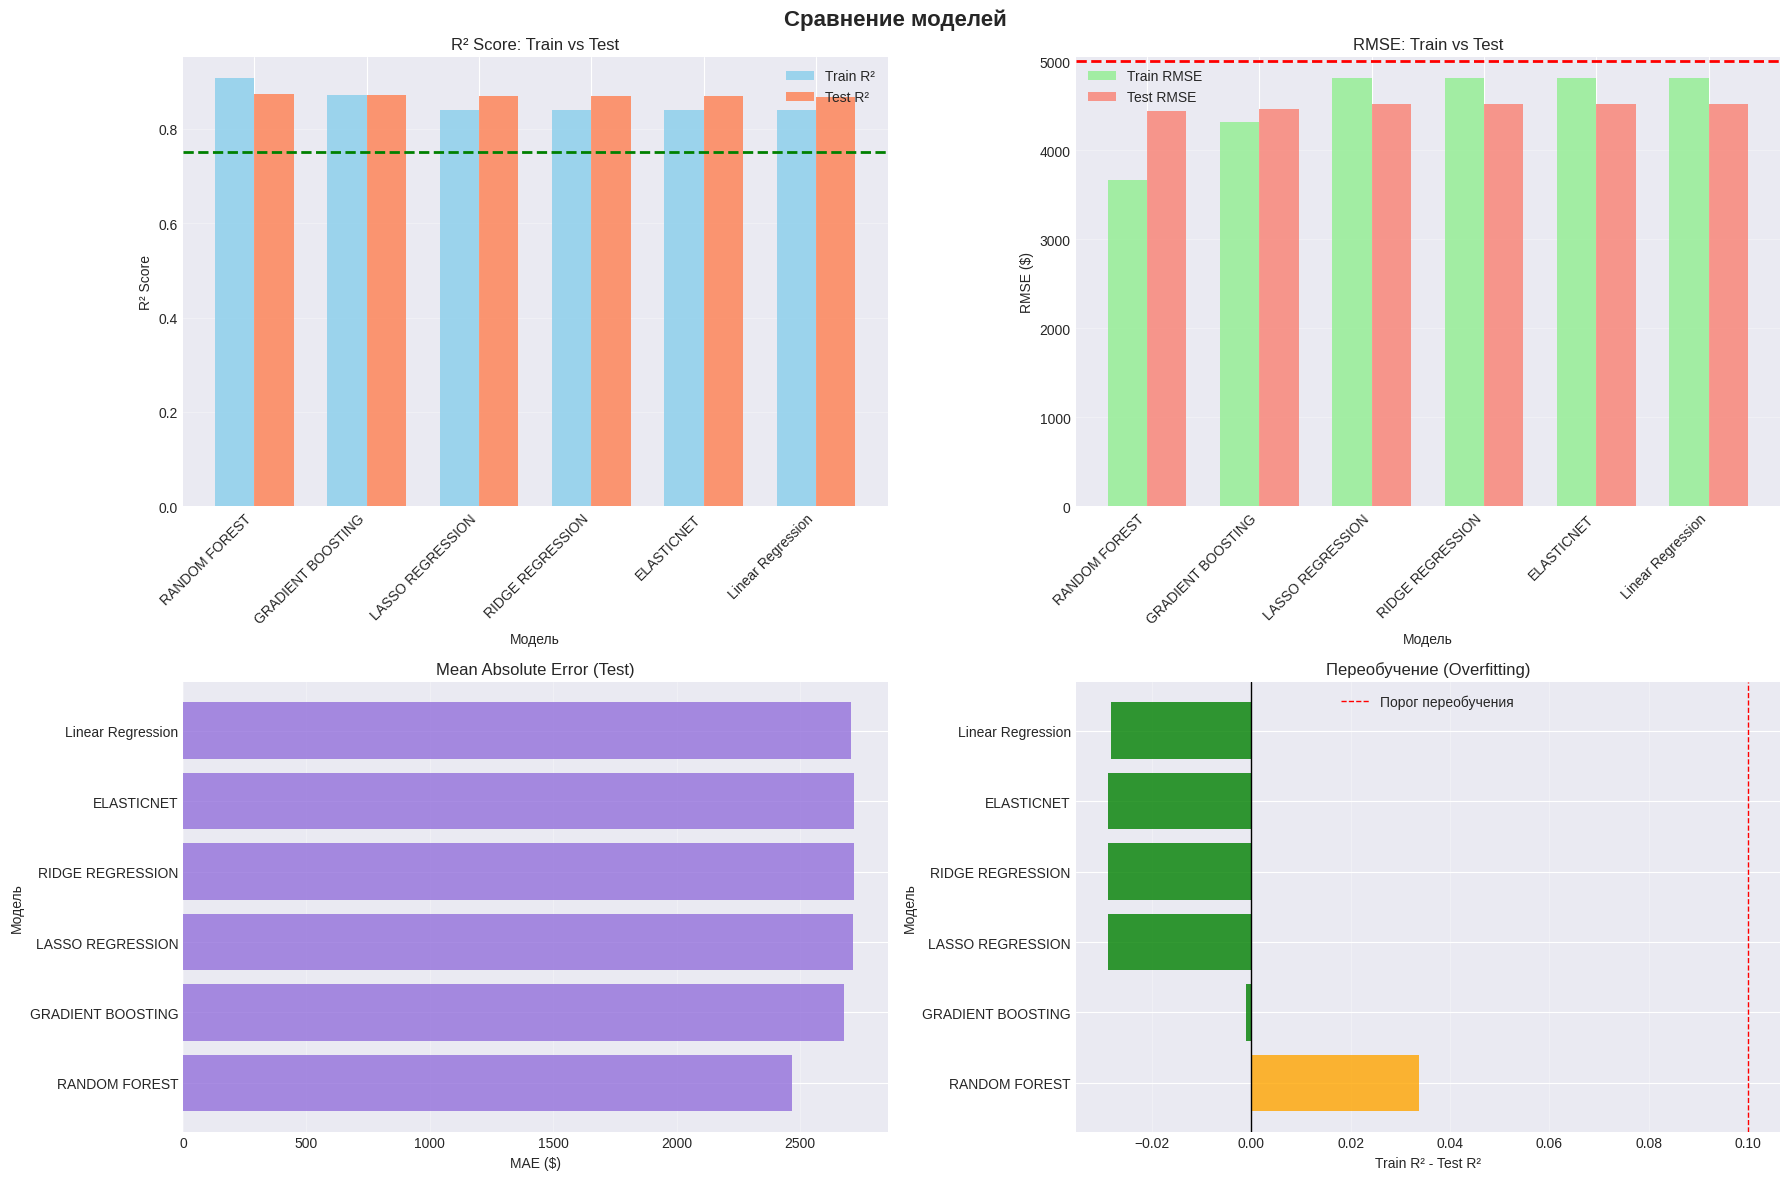

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Сравнение моделей', fontsize=16, fontweight='bold')

# 1. R² Score
ax1 = axes[0, 0]
models = all_results['model_name'].str.replace('BASELINE: ', '').str.replace(' (оптимизированная)', '')
train_r2 = all_results['train_r2']
test_r2 = all_results['test_r2']

x = np.arange(len(models))
width = 0.35

ax1.bar(x - width/2, train_r2, width, label='Train R²', alpha=0.8, color='skyblue')
ax1.bar(x + width/2, test_r2, width, label='Test R²', alpha=0.8, color='coral')
ax1.set_xlabel('Модель')
ax1.set_ylabel('R² Score')
ax1.set_title('R² Score: Train vs Test')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='Целевой R² = 0.75')

# 2. RMSE
ax2 = axes[0, 1]
train_rmse = all_results['train_rmse']
test_rmse = all_results['test_rmse']

ax2.bar(x - width/2, train_rmse, width, label='Train RMSE', alpha=0.8, color='lightgreen')
ax2.bar(x + width/2, test_rmse, width, label='Test RMSE', alpha=0.8, color='salmon')
ax2.set_xlabel('Модель')
ax2.set_ylabel('RMSE ($)')
ax2.set_title('RMSE: Train vs Test')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=5000, color='red', linestyle='--', linewidth=2, label='Целевой RMSE = $5000')

# 3. MAE
ax3 = axes[1, 0]
test_mae = all_results['test_mae']

ax3.barh(models, test_mae, alpha=0.8, color='mediumpurple')
ax3.set_xlabel('MAE ($)')
ax3.set_ylabel('Модель')
ax3.set_title('Mean Absolute Error (Test)')
ax3.grid(True, alpha=0.3, axis='x')

# 4. Переобучение
ax4 = axes[1, 1]
overfit = all_results['overfit']
colors = ['red' if x > 0.1 else 'green' if x < 0 else 'orange' for x in overfit]

ax4.barh(models, overfit, alpha=0.8, color=colors)
ax4.set_xlabel('Train R² - Test R²')
ax4.set_ylabel('Модель')
ax4.set_title('Переобучение (Overfitting)')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.axvline(x=0.1, color='red', linestyle='--', linewidth=1, label='Порог переобучения')
ax4.grid(True, alpha=0.3, axis='x')
ax4.legend()

plt.tight_layout()
plt.show()

## 27. Анализ предсказаний лучшей модели

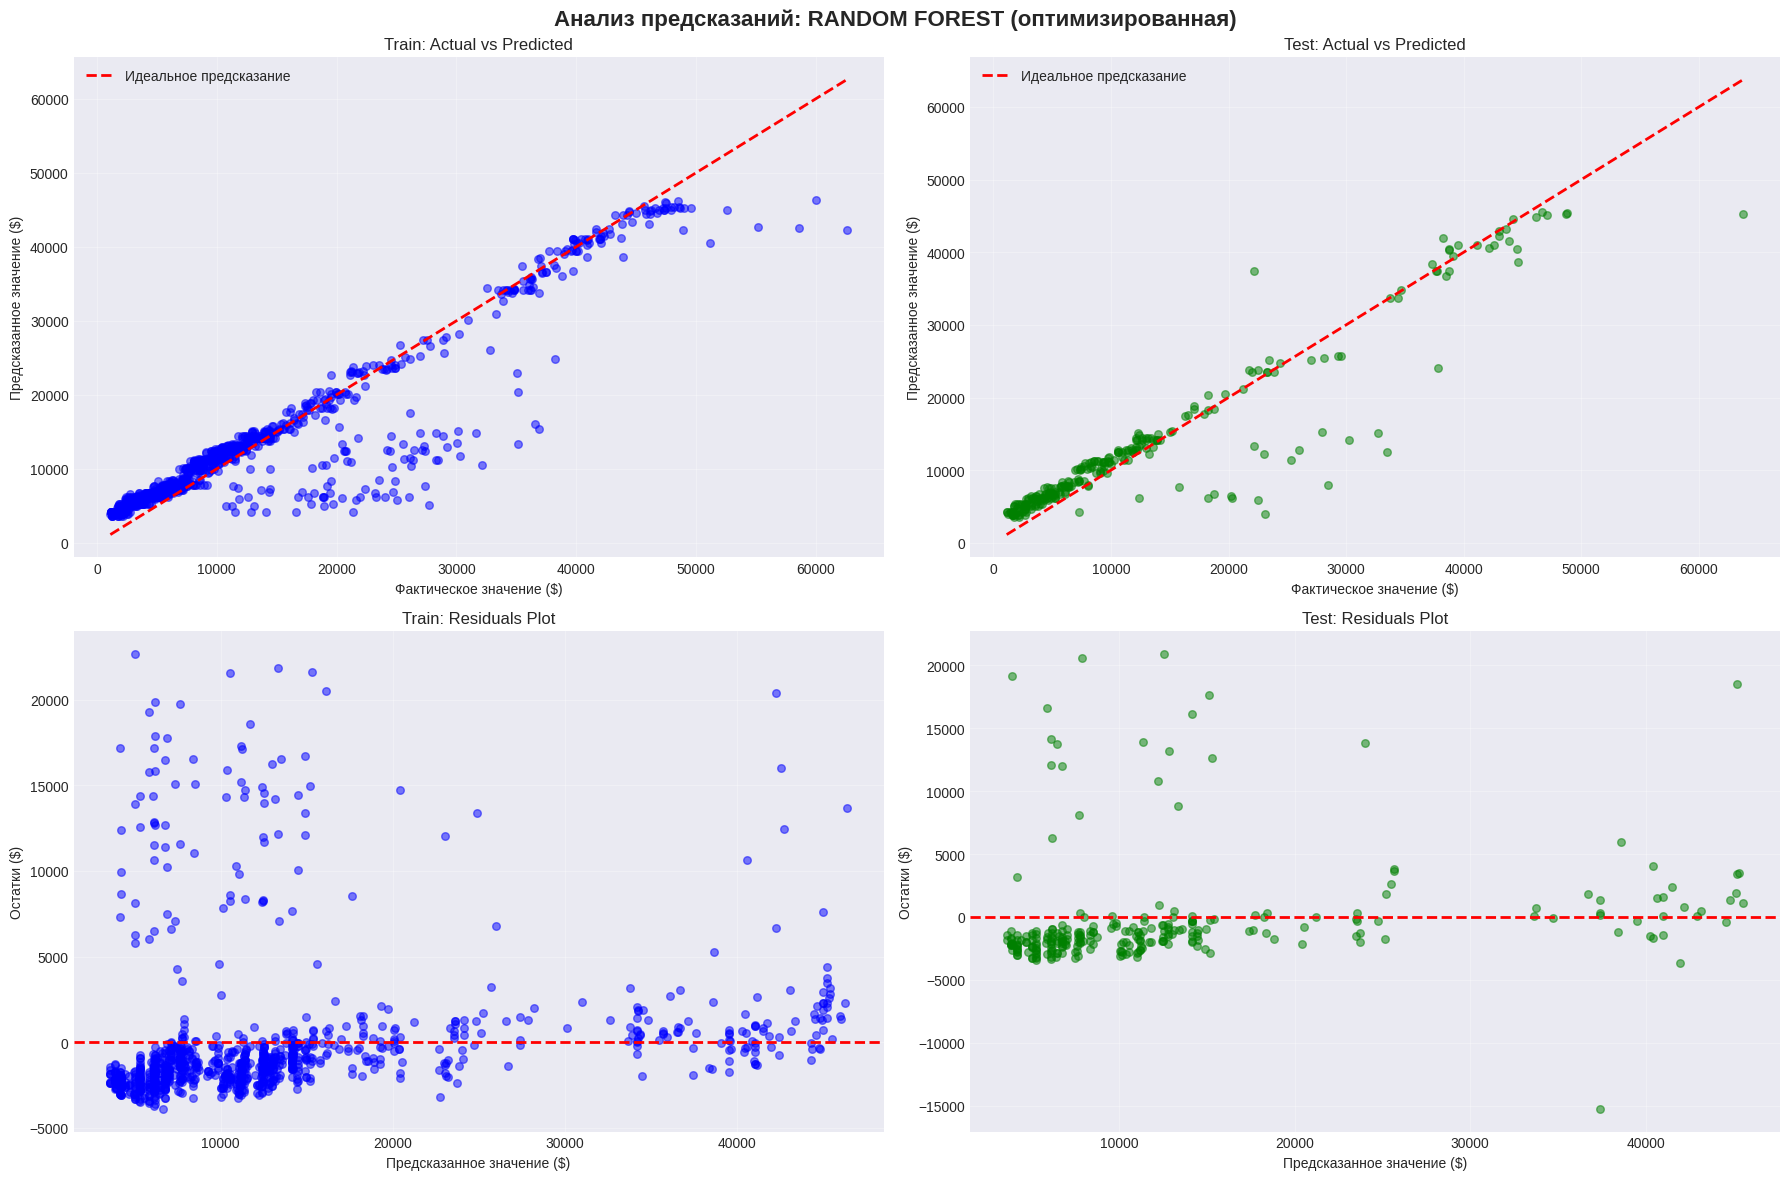

In [28]:
best_model = gb_grid.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f'Анализ предсказаний: {best_model_name}', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted (Train)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=30, color='blue')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
                'r--', lw=2, label='Идеальное предсказание')
axes[0, 0].set_xlabel('Фактическое значение ($)')
axes[0, 0].set_ylabel('Предсказанное значение ($)')
axes[0, 0].set_title('Train: Actual vs Predicted')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (Test)
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, s=30, color='green')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', lw=2, label='Идеальное предсказание')
axes[0, 1].set_xlabel('Фактическое значение ($)')
axes[0, 1].set_ylabel('Предсказанное значение ($)')
axes[0, 1].set_title('Test: Actual vs Predicted')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals (Train)
train_residuals = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, train_residuals, alpha=0.5, s=30, color='blue')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Предсказанное значение ($)')
axes[1, 0].set_ylabel('Остатки ($)')
axes[1, 0].set_title('Train: Residuals Plot')
axes[1, 0].grid(True, alpha=0.3)

# 4. Residuals (Test)
test_residuals = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, test_residuals, alpha=0.5, s=30, color='green')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Предсказанное значение ($)')
axes[1, 1].set_ylabel('Остатки ($)')
axes[1, 1].set_title('Test: Residuals Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 28. Распределение остатков

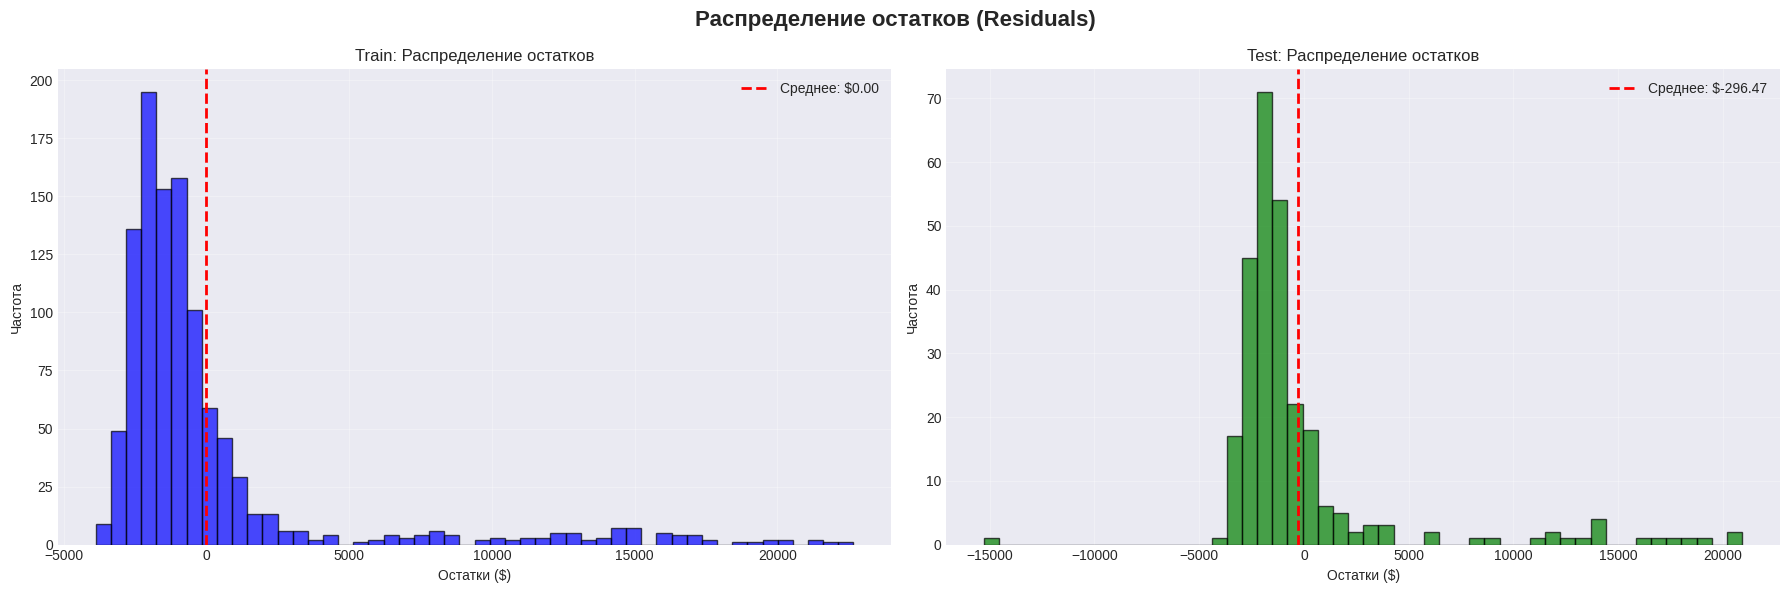


СТАТИСТИКА ОСТАТКОВ
Train:
  Среднее: $0.00
  Ст.откл.: $4321.08
  Мин: $-3882.19
  Макс: $22670.04

Test:
  Среднее: $-296.47
  Ст.откл.: $4459.13
  Мин: $-15260.83
  Макс: $20925.32


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Распределение остатков (Residuals)', fontsize=16, fontweight='bold')

# Train
axes[0].hist(train_residuals, bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(train_residuals.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Среднее: ${train_residuals.mean():.2f}')
axes[0].set_xlabel('Остатки ($)')
axes[0].set_ylabel('Частота')
axes[0].set_title('Train: Распределение остатков')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].hist(test_residuals, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(test_residuals.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Среднее: ${test_residuals.mean():.2f}')
axes[1].set_xlabel('Остатки ($)')
axes[1].set_ylabel('Частота')
axes[1].set_title('Test: Распределение остатков')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nСТАТИСТИКА ОСТАТКОВ")

print(f"Train:")
print(f"  Среднее: ${train_residuals.mean():.2f}")
print(f"  Ст.откл.: ${train_residuals.std():.2f}")
print(f"  Мин: ${train_residuals.min():.2f}")
print(f"  Макс: ${train_residuals.max():.2f}")
print(f"\nTest:")
print(f"  Среднее: ${test_residuals.mean():.2f}")
print(f"  Ст.откл.: ${test_residuals.std():.2f}")
print(f"  Мин: ${test_residuals.min():.2f}")
print(f"  Макс: ${test_residuals.max():.2f}")

## 29. Детальный отчет по метрикам

In [30]:
print("ДЕТАЛЬНЫЙ ОТЧЕТ ПО МЕТРИКАМ")


for model_name, model in [
    ("Linear Regression", baseline_model),
    ("Ridge (best)", ridge_grid.best_estimator_),
    ("Lasso (best)", lasso_grid.best_estimator_),
    ("ElasticNet (best)", elasticnet_grid.best_estimator_),
    ("Random Forest (best)", rf_grid.best_estimator_),
    ("Gradient Boosting (best)", gb_grid.best_estimator_)
]:
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print(f"\n{model_name}:")
    print(f"  R² Score:  {r2:.4f}")
    print(f"  RMSE:      ${rmse:,.2f}")
    print(f"  MAE:       ${mae:,.2f}")
    print(f"  MAPE:      {mape:.2f}%")

    print(f"\n  Критерии успеха:")
    print(f"    R² > 0.75:      {'✓ ДА' if r2 > 0.75 else '✗ НЕТ'} ({r2:.4f})")
    print(f"    RMSE < $5000:   {'✓ ДА' if rmse < 5000 else '✗ НЕТ'} (${rmse:,.2f})")

ДЕТАЛЬНЫЙ ОТЧЕТ ПО МЕТРИКАМ

Linear Regression:
  R² Score:  0.8682
  RMSE:      $4,523.36
  MAE:       $2,708.14
  MAPE:      32.14%

  Критерии успеха:
    R² > 0.75:      ✓ ДА (0.8682)
    RMSE < $5000:   ✓ ДА ($4,523.36)

Ridge (best):
  R² Score:  0.8686
  RMSE:      $4,516.15
  MAE:       $2,719.15
  MAPE:      32.08%

  Критерии успеха:
    R² > 0.75:      ✓ ДА (0.8686)
    RMSE < $5000:   ✓ ДА ($4,516.15)

Lasso (best):
  R² Score:  0.8687
  RMSE:      $4,515.58
  MAE:       $2,715.63
  MAPE:      32.12%

  Критерии успеха:
    R² > 0.75:      ✓ ДА (0.8687)
    RMSE < $5000:   ✓ ДА ($4,515.58)

ElasticNet (best):
  R² Score:  0.8686
  RMSE:      $4,516.31
  MAE:       $2,718.72
  MAPE:      32.08%

  Критерии успеха:
    R² > 0.75:      ✓ ДА (0.8686)
    RMSE < $5000:   ✓ ДА ($4,516.31)

Random Forest (best):
  R² Score:  0.8732
  RMSE:      $4,437.67
  MAE:       $2,468.88
  MAPE:      31.20%

  Критерии успеха:
    R² > 0.75:      ✓ ДА (0.8732)
    RMSE < $5000:   ✓ ДА ($4,43

## 30. Итоговые выводы

In [31]:
print("ИТОГОВЫЕ ВЫВОДЫ")


print("\n1. КЛЮЧЕВЫЕ ФАКТОРЫ, ВЛИЯЮЩИЕ НА СТОИМОСТЬ СТРАХОВКИ:")
print("   • Smoker (статус курения) - самый важный фактор")
print("   • Age (возраст) - умеренная положительная корреляция")
print("   • BMI (индекс массы тела) - умеренная положительная корреляция")
print("   • Взаимодействия smoker×bmi и age×smoker улучшают предсказания")

print("\n2. КАЧЕСТВО МОДЕЛЕЙ:")
print(f"   • Лучшая модель: {best_model_name}")
print(f"   • Test R²: {best_r2:.4f}")
print(f"   • Test RMSE: ${best_rmse:,.2f}")

print("\n3. РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:")
print("   • Использовать модель для автоматического расчета стоимости полисов")
print("   • Предлагать программы отказа от курения со скидками")
print("   • Мониторить клиентов с высоким BMI")
print("   • Регулярно обновлять модель новыми данными")


ИТОГОВЫЕ ВЫВОДЫ

1. КЛЮЧЕВЫЕ ФАКТОРЫ, ВЛИЯЮЩИЕ НА СТОИМОСТЬ СТРАХОВКИ:
   • Smoker (статус курения) - самый важный фактор
   • Age (возраст) - умеренная положительная корреляция
   • BMI (индекс массы тела) - умеренная положительная корреляция
   • Взаимодействия smoker×bmi и age×smoker улучшают предсказания

2. КАЧЕСТВО МОДЕЛЕЙ:
   • Лучшая модель: RANDOM FOREST (оптимизированная)
   • Test R²: 0.8732
   • Test RMSE: $4,437.67

3. РЕКОМЕНДАЦИИ ДЛЯ БИЗНЕСА:
   • Использовать модель для автоматического расчета стоимости полисов
   • Предлагать программы отказа от курения со скидками
   • Мониторить клиентов с высоким BMI
   • Регулярно обновлять модель новыми данными
